In [1]:
from google.colab import drive
from huggingface_hub import hf_hub_download

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/data"

hf_hub_download(repo_id="benmoseley/ese-dl-2025-26-group-project", filename="train.h5", repo_type="dataset", local_dir=data_path)
hf_hub_download(repo_id="benmoseley/ese-dl-2025-26-group-project", filename="events.csv", repo_type="dataset", local_dir=data_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


'/content/drive/MyDrive/data/events.csv'

In [2]:
!ls /content/drive/MyDrive
%cd /content/drive/MyDrive/project_Lee
!pip -q install livelossplot
%pip install -e .

'Colab Notebooks'   data   Lee	 models   project_Lee
/content/drive/MyDrive/project_Lee
Obtaining file:///content/drive/MyDrive/project_Lee
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for my_package (pyproject.toml) ... done
  Created wheel for my_package: filename=my_package-0.1.0-0.editable-py3-none-any.whl size=1242 sha256=48cf9dca353a4294e868ea72aa95a9b8e5870c1383fe91538497272cccfdad74
  Stored in directory: /tmp/pip-ephem-wheel-cache-whs4jf2a/wheels/c4/d7/ae/2ad3df9b4cb85bc0e7aaa88081d88b08744cfb4af07722ff3d
Successfully built my_package
  Attempting uninstall: my_package
    Found existing installation: my_package 0.1.0
    Uninstalling my_package-0.1.0:
      Successfully uninstalled my_package-0.1.0


In [3]:
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io

from sklearn.model_selection import train_test_split
import torch
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm


In [8]:
from my_package.data import create_filtered_h5, create_dataloaders

create_filtered_h5(
    source_path="/content/drive/MyDrive/data/train.h5",
    target_path="data/train_vil_only.h5",
    dataset_key="vil",
)

'Filtered file created.'

In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled   = False
    return True

set_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}")

Running on: cuda


In [5]:
batch_size = 2
lr = 3e-4
nepochs = 5
wd = 1e-5
num_workers = 0
test_size=0.2

T_total = 36
in_len = 12
out_len = 12
num_starts = T_total - (in_len + out_len) + 1

In [6]:
from my_package.model import ConvRNN

model = ConvRNN(in_channels=1, hidden_dim=64, layers=3).to(device)
print(f"PredRNN Model Created. Params: {sum(p.numel() for p in model.parameters())}")
print(model)

PredRNN Model Created. Params: 1222481
ConvRNN(
  (encoder): Encoder(
    (enc): Sequential(
      (0): BasicConv2d(
        (conv): Sequential(
          (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): GroupNorm(4, 32, eps=1e-05, affine=True)
          (2): LeakyReLU(negative_slope=0.2, inplace=True)
        )
      )
      (1): BasicConv2d(
        (conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): GroupNorm(4, 64, eps=1e-05, affine=True)
          (2): LeakyReLU(negative_slope=0.2, inplace=True)
        )
      )
      (2): BasicConv2d(
        (conv): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): GroupNorm(4, 64, eps=1e-05, affine=True)
          (2): LeakyReLU(negative_slope=0.2, inplace=True)
        )
      )
    )
  )
  (decoder): Decoder(
    (dec): Sequential(
      (0): Upsample

In [7]:
from my_package.data import create_dataloaders

h5_path = "data/train_vil_only.h5"
in_len = 12
out_len = 12
lr = 1e-3
wd = 1e-2
nepochs = 10
num_workers = 4

# 4. Initialize DataLoaders
train_loader, val_loader = create_dataloaders(
    h5_path=h5_path,
    num_starts=num_workers,
    in_len=in_len,
    out_len=out_len,
    batch_size=2
)

# 5. Define Model, Loss, and Optimizer
# model = YourModel().to(device)
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

# Scheduler requires the loader length
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=lr,
    steps_per_epoch=len(train_loader),
    epochs=nepochs
)


Loading indices from data/train_vil_only.h5...
Total Events: 800 | Train: 640 | Val: 160
DataLoaders ready.


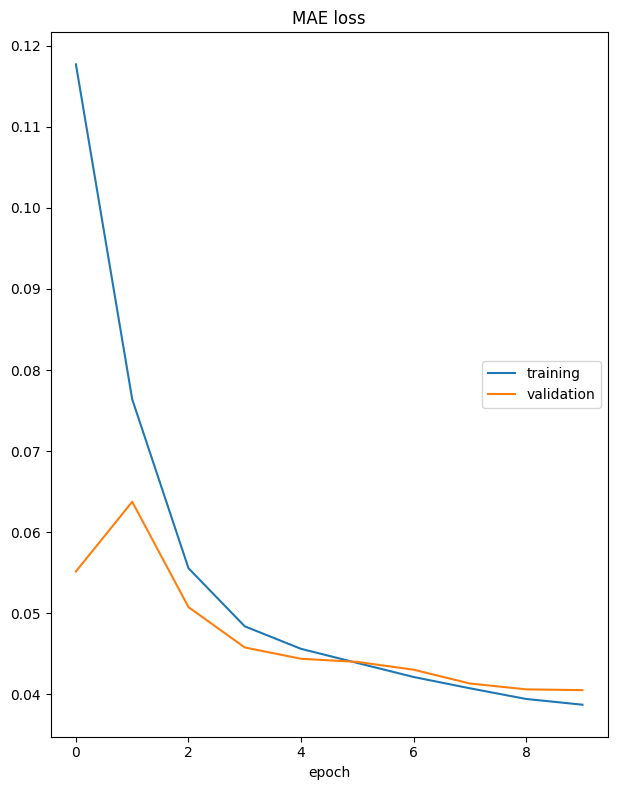

MAE loss
	training         	 (min:    0.039, max:    0.118, cur:    0.039)
	validation       	 (min:    0.041, max:    0.064, cur:    0.041)
Saved Best Model! Loss: 0.040517
Train: 0.038720 | Val: 0.040517
--------------------------------------------------


In [ ]:
from my_package.train import run_training

run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    nepochs=nepochs,
    input_len=12,
    total_len=24,
    save_path="convRNN_baseline.pth",
)


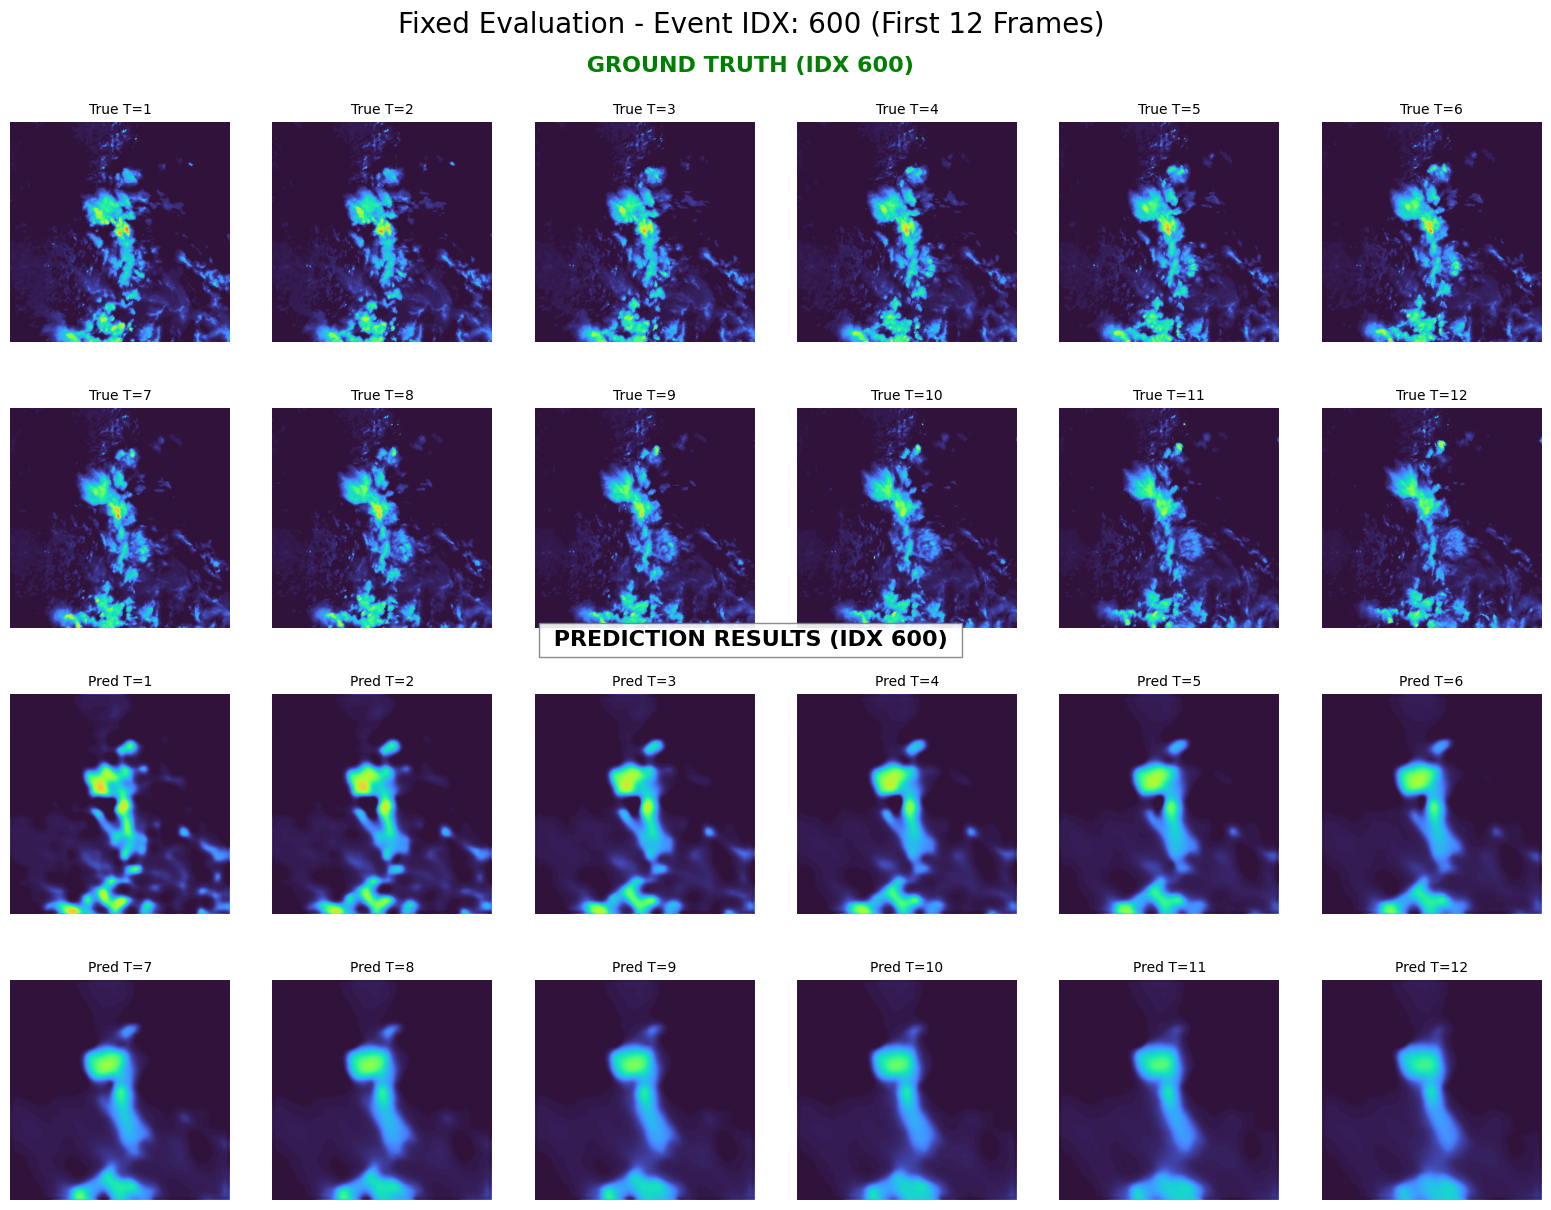

In [8]:
from my_package.utils import show_fixed_event_prediction

val_dataset = val_loader.dataset

inputs_origin, targets_origin, preds = show_fixed_event_prediction(
    model=model,
    val_dataset=val_dataset,
    device=device,
    fixed_event_idx=600,
    n_frames=12,
    ckpt_path="/content/drive/MyDrive/project_Lee/convRNN_baseline.pth"
)



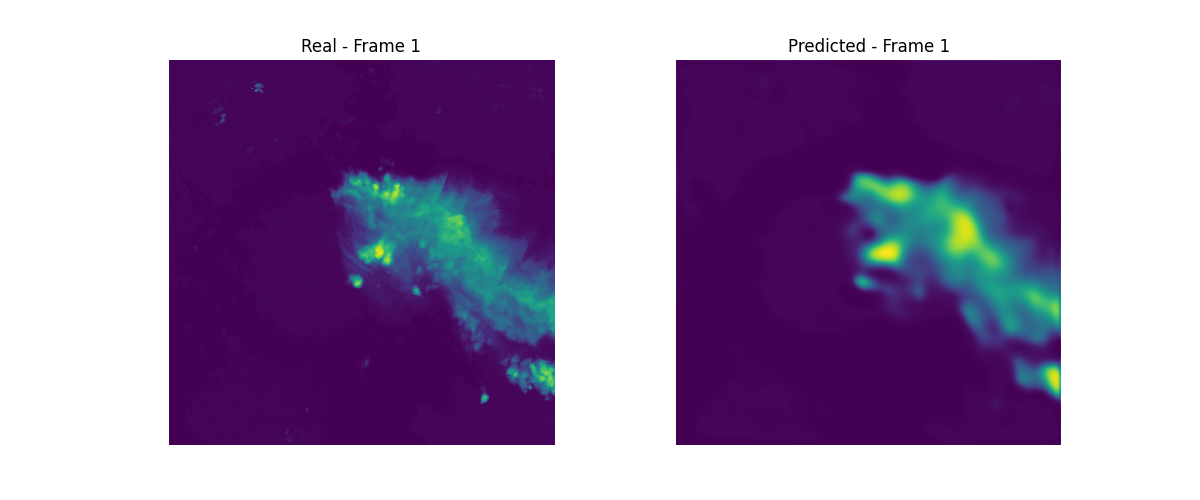

In [15]:
from my_package.utils import plot_prediction_metrics_all_events, create_prediction_gif
from IPython.display import Image

gif_path = create_prediction_gif(val_dataset, model, device)


Image(open("prediction.gif",'rb').read())


Calculating average metrics for 640 events...


100%|██████████| 640/640 [11:24<00:00,  1.07s/it]


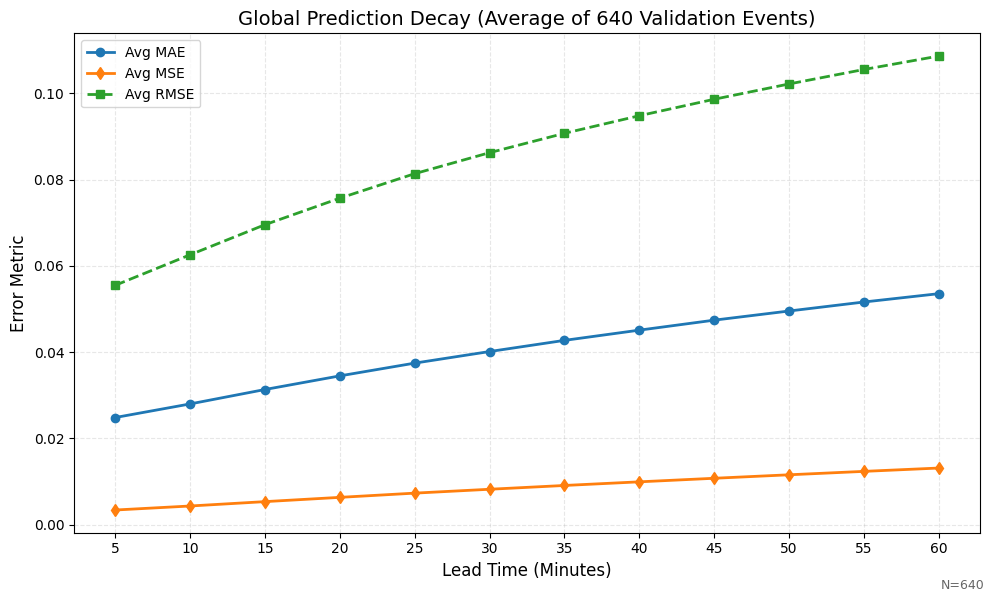

In [16]:
from my_package.utils import plot_prediction_metrics_all_events

plot_prediction_metrics_all_events(model, val_dataset, device)